# 01 — EDA

Display only. All logic lives in `src/s6e7/` (CLAUDE.md rule 5).
Tables carry the numbers; the figures from `src/s6e7/plots.py` carry the shape of each
distribution — both read against the same decisions.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import polars as pl

from s6e7 import eda, io, plots

plt.rcParams["figure.dpi"] = 120
pl.Config.set_tbl_rows(30)

polars.config.Config

In [2]:
train = io.load_train()
test = io.load_test()

train.shape, test.shape

((690088, 15), (295753, 14))

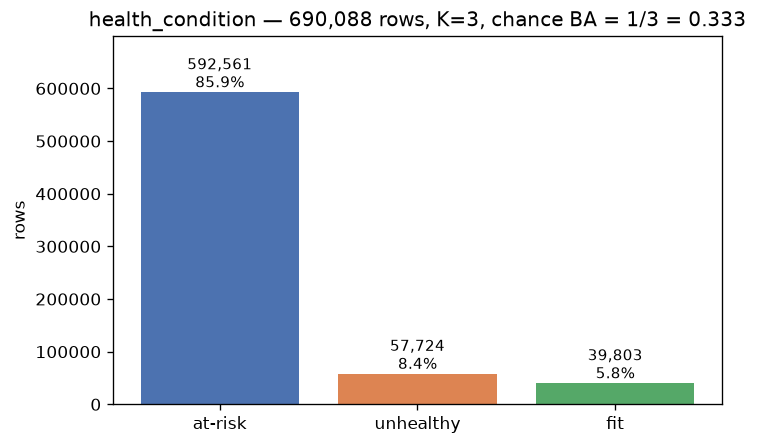

In [3]:
plots.target_overview(train, io.TARGET)

## Step 1 — column overview

**Decision:** which columns are numeric vs categorical, which need imputation, and which
are effectively constant.

`n_unique` excludes nulls, and that exclusion is the point. Polars' own `n_unique` counts
null as a distinct value, which reports a 3-level categorical with missing data as having
4 levels — and you would go looking for a level that does not exist.

In [4]:
eda.overview(train)

column,dtype,nulls,null_pct,n_unique
str,str,i64,f64,i64
"""id""","""UInt32""",0,0.0,690088
"""health_condition""","""String""",0,0.0,3
"""sleep_duration""","""Float32""",75999,11.01,701
"""heart_rate""","""Float32""",7833,1.14,537
"""bmi""","""Float32""",13898,2.01,1596
"""calorie_expenditure""","""Float32""",52853,7.66,2101
"""step_count""","""Float32""",13916,2.02,12807
"""exercise_duration""","""Float32""",6901,1.0,856
"""water_intake""","""Float32""",43477,6.3,400


In [5]:
eda.overview(test)

column,dtype,nulls,null_pct,n_unique
str,str,i64,f64,i64
"""id""","""UInt32""",0,0.0,295753
"""sleep_duration""","""Float32""",32571,11.01,692
"""heart_rate""","""Float32""",3357,1.14,526
"""bmi""","""Float32""",5956,2.01,1548
"""calorie_expenditure""","""Float32""",22652,7.66,2068
"""step_count""","""Float32""",5964,2.02,12196
"""exercise_duration""","""Float32""",2958,1.0,817
"""water_intake""","""Float32""",18633,6.3,392
"""diet_type""","""String""",2958,1.0,3


## Step 2 — category levels

**Decision:** encoding strategy, and whether naive encoders are safe.

Two things can go wrong, and they are the two set differences between the level sets:

- **in test but not train** — breaks a fitted encoder at predict time. Ordinal raises or
  substitutes a fill; one-hot emits an all-zeros row the model never saw in training;
  target encoding has no statistic and falls back to the global mean.
- **in train but not test** — harmless, just dead weight.

**We want both empty**, because then none of that handling has to be written, tested and
kept consistent across every fold and every encoder. It removes a category of code and a
category of bug — and the safety is a property of the *data*, never of the pipeline.

Levels print alphabetically, which is rarely the meaningful order — `high, low, medium`
sorts nothing like `low < medium < high`. Reading which of these are genuinely *ordinal*
is the judgement this step exists to support.

In [6]:
eda.category_levels(train, io.CATEGORICAL_COLS, test)

column,n_levels,levels,test_only,train_only
str,i64,str,str,str
"""diet_type""",3,"""balanced, non-veg, veg""","""""",""""""
"""stress_level""",3,"""high, low, medium""","""""",""""""
"""sleep_quality""",3,"""average, good, poor""","""""",""""""
"""physical_activity_level""",3,"""active, moderate, sedentary""","""""",""""""
"""smoking_alcohol""",3,"""no, occasional, yes""","""""",""""""
"""gender""",3,"""female, male, other""","""""",""""""


## Step 3 — class rate per level

**Decision:** is the target *monotone* in the declared level ordering?

Each `p_<class>` cell is a conditional class rate — of the rows at this level, what
fraction are this class.

Read each column's block top to bottom: monotone in the declared order means the rate
moves one way and does not turn around. That is the empirical claim an ordinal integer
encoding makes, and the precondition for a monotone constraint later. A zigzag means the
ordering is not real.

**Why a zigzag matters.** With three levels a threshold split can only produce
$\{\ell_1\} \mid \{\ell_2, \ell_3\}$ or $\{\ell_1, \ell_2\} \mid \{\ell_3\}$ — **the
middle level cannot be isolated.** So the real question is not "is it monotone?" but
*"are the levels I need to isolate contiguous in this ordering?"* An interesting middle
is the case that hurts; interesting extremes are fine.

Orderings come from `io.ORDINAL_LEVELS`, a **modelling judgement, not a fact**. Edit it
there if you disagree.

Nulls appear as their own level, so this doubles as the missingness test for the
categoricals. Compare every row against the global rates: `at-risk` 0.859, `unhealthy`
0.084, `fit` 0.058.

In [7]:
eda.level_target_rates(train, io.CATEGORICAL_COLS, io.TARGET, io.ORDINAL_LEVELS)

column,level,rows,share_pct,p_at-risk,p_fit,p_unhealthy
str,str,i64,f64,f64,f64,f64
"""diet_type""","""balanced""",226888,32.88,0.8514,0.0612,0.0874
"""diet_type""","""non-veg""",224867,32.59,0.8678,0.0516,0.0806
"""diet_type""","""veg""",231432,33.54,0.8567,0.0604,0.083
"""diet_type""","""<null>""",6901,1.0,0.8676,0.0509,0.0816
"""stress_level""","""low""",167708,24.3,0.7967,0.2006,0.0028
"""stress_level""","""medium""",261819,37.94,0.9939,0.003,0.0031
"""stress_level""","""high""",177750,25.76,0.7178,0.0035,0.2787
"""stress_level""","""<null>""",82811,12.0,0.8589,0.0575,0.0836
"""sleep_quality""","""poor""",212166,30.74,0.8296,0.0346,0.1358


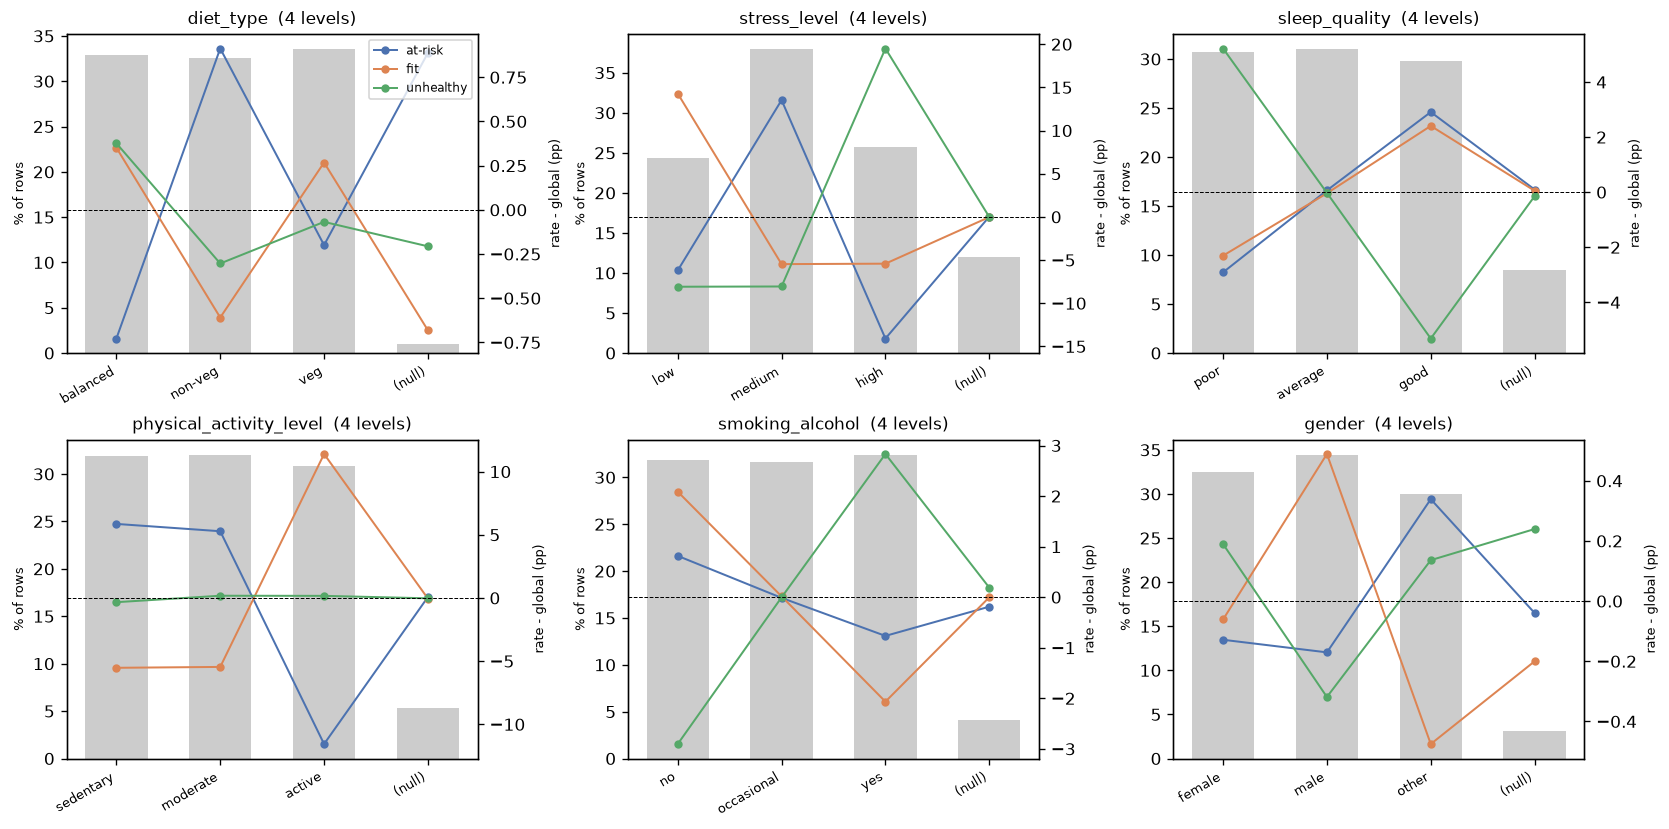

In [8]:
# The same table as a picture: grey bars = level shares, colored markers = per-class
# rate deviation from the global rate in pp. A zigzag in the markers is the
# non-contiguity warning the encoding judgement rests on.
plots.categorical_grid(train, io.CATEGORICAL_COLS, io.TARGET)

## Step 4 — numeric summary

**Decision:** which features need transformation, whether a bound is a real limit or a
clip, and whether the distribution hides a point mass.

**`grid`** — the typical quantisation step: sort the distinct values, take the **median**
gap between neighbours. Not the minimum. A single off-grid value splits one normal step
into two smaller ones and drags the minimum down tenfold, making a clean grid look
ragged — here a 0.1 grid reported as 0.03 off one row in 690,000. `min_gap` gets its own
column so that contamination stays *visible* instead of corrupting the number you meant
to read.

**`pct_at_min` / `pct_at_max`** — clipping. A genuine distribution *tapers* at its
extremes; a clipped one *piles up* there. The tell is the order of magnitude: **a clip
shows percent-at-bound in whole numbers, a truncated sampling range in hundredths.**

**`mode_pct`** — the share of the single most common value, which catches a point mass
*anywhere*. The bound percentages only find a spike that happens to land on a boundary;
this finds zero-inflation, a sentinel, or a default wherever it sits.

**`skew`** — and why it does not matter here. Transformations are moot for a GBDT: a
split asks "is $x \le \tau$?", a question about **rank order**, and every monotone
transform preserves rank order, so $\log x$ produces the identical tree. This table earns
its place for clipping and point masses, and for any linear model later in the blend.

In [9]:
eda.numeric_summary(train, io.NUMERIC_COLS)

column,n_unique,min,max,grid,min_gap,mode,mode_pct,pct_at_min,pct_at_max,mean,std,skew
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sleep_duration""",701,3.0,10.0,0.01,0.009999,7.16,0.56,0.01,0.03,6.993,1.215,-0.008
"""heart_rate""",537,50.0,107.699997,0.099998,0.029999,74.0,0.58,0.01,0.0,75.097,8.175,0.0
"""bmi""",1596,16.0,34.82,0.01,0.000999,23.440001,0.33,0.03,0.0,22.985,2.482,0.025
"""calorie_expenditure""",2101,1200.0,3580.0,1.0,1.0,2201.0,0.41,0.0,0.0,2226.085,347.532,-0.184
"""step_count""",12807,1002.0,14999.0,1.0,1.0,12182.0,0.12,0.0,0.0,8615.953,3929.4,-0.18
"""exercise_duration""",856,0.0,99.800003,0.1,0.02,0.0,2.41,2.41,0.0,38.751,14.742,-0.375
"""water_intake""",400,0.5,4.72,0.01,0.01,2.37,1.04,0.05,0.0,2.189,0.518,0.11


## Step 5 — is missingness a feature?

**Decision:** add missing-indicator columns, or don't bother.

Compare the class rate on rows where a column is missing against rows where it is
present. If they differ, missingness carries information and deserves an indicator. If
they match, the nulls were injected at random: an indicator is dead weight, and clever
imputation buys nothing either.

**Judge the size against sampling noise, not against zero.** The missing rows are usually
a small slice, so `abs_diff` has real wobble in it. A difference is worth taking
seriously once it clears a few standard errors:

$$\text{SE} \;\approx\; \sqrt{\frac{p\,(1-p)}{n_{\text{missing}}}}$$

At $n_{\text{missing}} = 6{,}901$ and $p \approx 0.08$, that is about 0.003 — so a
difference of 0.055 is roughly 18 SE and unmistakable, while 0.004 is nothing.

Sorted by `abs_diff`, largest first. The `<null>` rows in step 3 already hint at the
answer for the categoricals.

In [ ]:
eda.missing_vs_target(train, io.FEATURE_COLS, io.TARGET).sort("abs_diff", descending=True).head(12)

column,target_class,n_missing,p_when_missing,p_when_present,abs_diff
str,str,i64,f64,f64,f64
"""bmi""","""unhealthy""",13898,0.0293,0.0848,0.0555
"""bmi""","""at-risk""",13898,0.8888,0.8581,0.0307
"""bmi""","""fit""",13898,0.082,0.0572,0.0248
"""heart_rate""","""at-risk""",7833,0.8708,0.8585,0.0123
"""heart_rate""","""unhealthy""",7833,0.0739,0.0838,0.0098
"""diet_type""","""at-risk""",6901,0.8676,0.8586,0.009
"""exercise_duration""","""at-risk""",6901,0.8509,0.8588,0.0079
"""diet_type""","""fit""",6901,0.0509,0.0577,0.0069
"""exercise_duration""","""unhealthy""",6901,0.0887,0.0836,0.0051


### Do nulls co-occur?

**Decision:** is there one shared missingness mask, or 13 independent draws?

Equal null *counts* across columns prove nothing — they are usually just arithmetic
($690{,}088 \times 1\% = 6{,}900.88 \to 6{,}901$). Only the **joint** count separates the
two stories. If columns $a$ and $b$ go missing independently, the number of rows missing
both should be

$$N \, p_a \, p_b \qquad\Longrightarrow\qquad
\texttt{ratio} = \frac{\texttt{both\_missing}}{N \, p_a \, p_b}$$

`ratio` ≈ 1 means the two columns drop values independently; `ratio` ≫ 1 means they fail
together. **Compare observed co-missingness against its expectation — never one column's
count against another's.**

This is the pairwise version of the question. The per-*row* version, which is what
eventually broke the i.i.d. premise, is in `02_train_test_shift.ipynb`.

In [11]:
eda.missing_cooccurrence(train, io.FEATURE_COLS).head(10)

col_a,col_b,both_missing,expected,ratio
str,str,i64,f64,f64
"""diet_type""","""gender""",630,213.7,2.95
"""heart_rate""","""gender""",267,242.6,1.1
"""bmi""","""physical_activity_level""",811,737.5,1.1
"""diet_type""","""smoking_alcohol""",313,285.8,1.1
"""bmi""","""diet_type""",150,139.0,1.08
"""exercise_duration""","""gender""",228,213.7,1.07
"""sleep_duration""","""diet_type""",795,760.0,1.05
"""bmi""","""sleep_quality""",1221,1174.8,1.04
"""exercise_duration""","""diet_type""",72,69.0,1.04


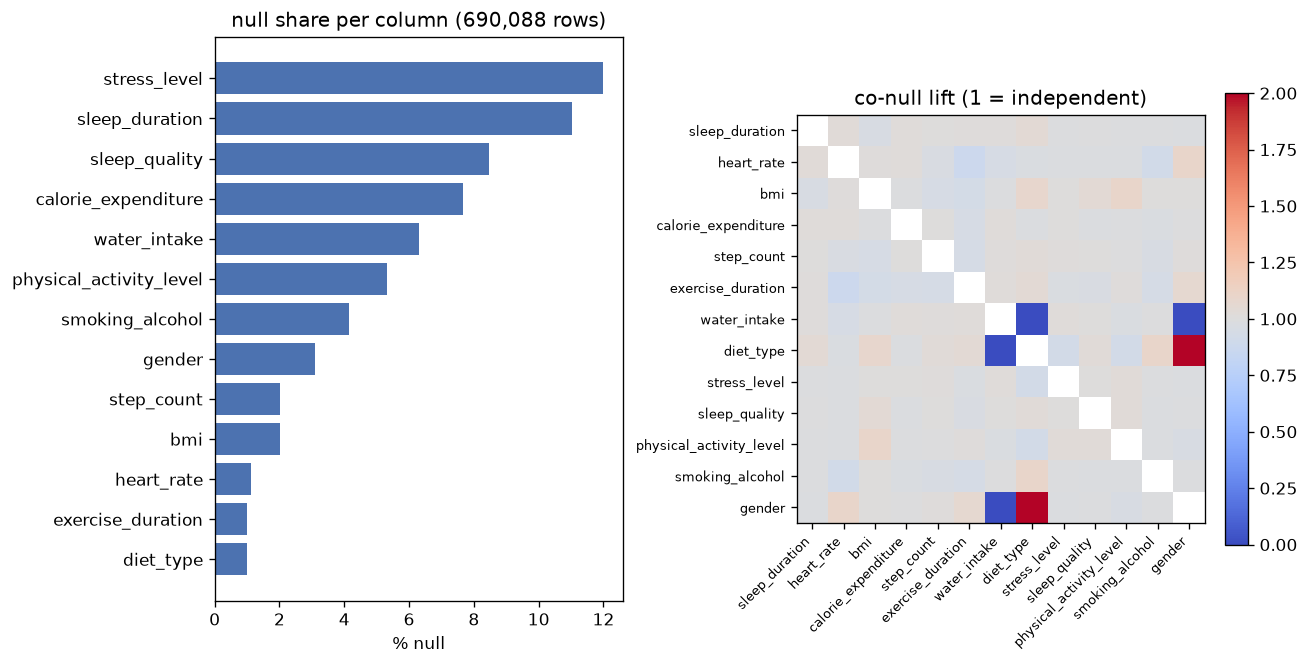

In [12]:
# Left: null share per column. Right: the pairwise ratio above as a heatmap —
# co-null lift, observed / (p_a · p_b), 1 = independent. The diet_type × gender 2.95
# stands out; everything else sits at 1.
plots.missingness(train)

## Step 6 — which numeric features carry signal

**Decision:** which features to plot, and what to expect from a baseline.

**`spread_sd`** is the gap between the largest and smallest class mean, divided by the
column's own standard deviation. Dividing is what makes steps comparable to hours. Call
it $d$.

**`overlap_pct` and `best_split_acc` restate $d$ in units you can act on.** Model two
classes as normal curves of equal width whose means are $d$ standard deviations apart.
Then:

$$\texttt{overlap\_pct} = 2\,\Phi(-d/2) \qquad\qquad \texttt{best\_split\_acc} = \Phi(d/2)$$

So $d = 2.1$ means 29% of the two curves overlap and a **single threshold** separates the
extreme classes about 86% of the time. $d = 0.05$ means 98% overlap and 0.51 — a coin
flip. This is what turns an abstract effect size into "what could one cut actually
score".

**Where $\Phi(d/2)$ comes from.** Draw the two curves and put the threshold at their
crossing point — the **midpoint** between the means, since the curves are identical in
shape. Nudge it either way and you misclassify more of one class than you rescue of the
other, so the midpoint is the best possible cut. That midpoint sits $d/2$ standard
deviations from *each* mean. A class-A row is called correctly when it falls on A's side
of the cut, which happens with probability $P(Z < d/2) = \Phi(d/2)$; by symmetry class B
scores the same, so the cut's (balanced) accuracy is $\Phi(d/2)$. The two tails caught on
the wrong side — $\Phi(-d/2)$ each — are exactly the area the curves share:
$2\,\Phi(-d/2)$.

**The normal model is a ruler, not a claim about the data.** Nothing here asserts that
`sleep_duration` is Gaussian. The question is "in the best-behaved world where two
classes sit $d$ apart, what would one cut score?" — and that number becomes the unit we
read $d$ in. This is standard statistics, not a Kaggle habit: $d$ is Cohen's effect size,
and the two-equal-Gaussian setup is the model behind linear discriminant analysis. Real
data with the same $d$ lands near the ruler's number, usually a little under it.

**The equal-priors assumption is a feature here, not a flaw.** Accuracy under equal
priors *is* balanced accuracy for two classes, so `best_split_acc` already reads in the
competition metric's units — no correction needed.

**How to read the table:**

- $d \gtrsim 1$ — a workhorse. `sleep_duration` at $d = 2.13$: one cut alone reaches
  0.857 on the extreme classes; expect it at the top of every importance plot.
- $d \approx 0.3$–$1$ — `bmi`, `step_count`, `exercise_duration`, `calorie_expenditure`:
  no single cut wins, but a tree stacks many cuts and interactions; this band is where
  the model earns its keep over a rule.
- $d \lesssim 0.1$ — `heart_rate` (0.055), `water_intake` (0.019): the class **means**
  carry nothing; 0.51 is a coin flip. Not yet proof the feature is dead — that verdict
  needs the density plot, because of blind spot 2 below.

Build density plots **only** for the features that score here.

Three blind spots:

1. Dividing by the *overall* std rather than the pooled within-class std understates
   separation, so these numbers are **conservative**.
2. It compares means only. Equal means with different variances score $d = 0$ and are
   still separable — exactly where a plot beats a table.
3. With three classes it reads only the extremes and is blind to the middle. A feature
   that splits one class off while leaving the other two superimposed scores the same as
   one that separates all three. Under a macro metric those are not equally useful.
   **Read the per-class means, not just the ranking.**

In [13]:
eda.class_profile(train, io.NUMERIC_COLS, io.TARGET)

column,mean_at-risk,mean_fit,mean_unhealthy,overall_std,spread_sd,overlap_pct,best_split_acc
str,f64,f64,f64,f64,f64,f64,f64
"""sleep_duration""",7.086,7.954,5.366,1.215,2.1295,28.7,0.857
"""bmi""",22.95,21.829,24.123,2.482,0.9244,64.4,0.678
"""step_count""",8406.706,11651.307,8670.234,3929.4,0.8257,68.0,0.66
"""exercise_duration""",37.965,50.042,39.044,14.742,0.8192,68.2,0.659
"""calorie_expenditure""",2214.943,2363.992,2245.42,347.532,0.4289,83.0,0.585
"""heart_rate""",75.101,74.804,75.257,8.175,0.0554,97.8,0.511
"""water_intake""",2.189,2.179,2.189,0.518,0.0192,99.2,0.504


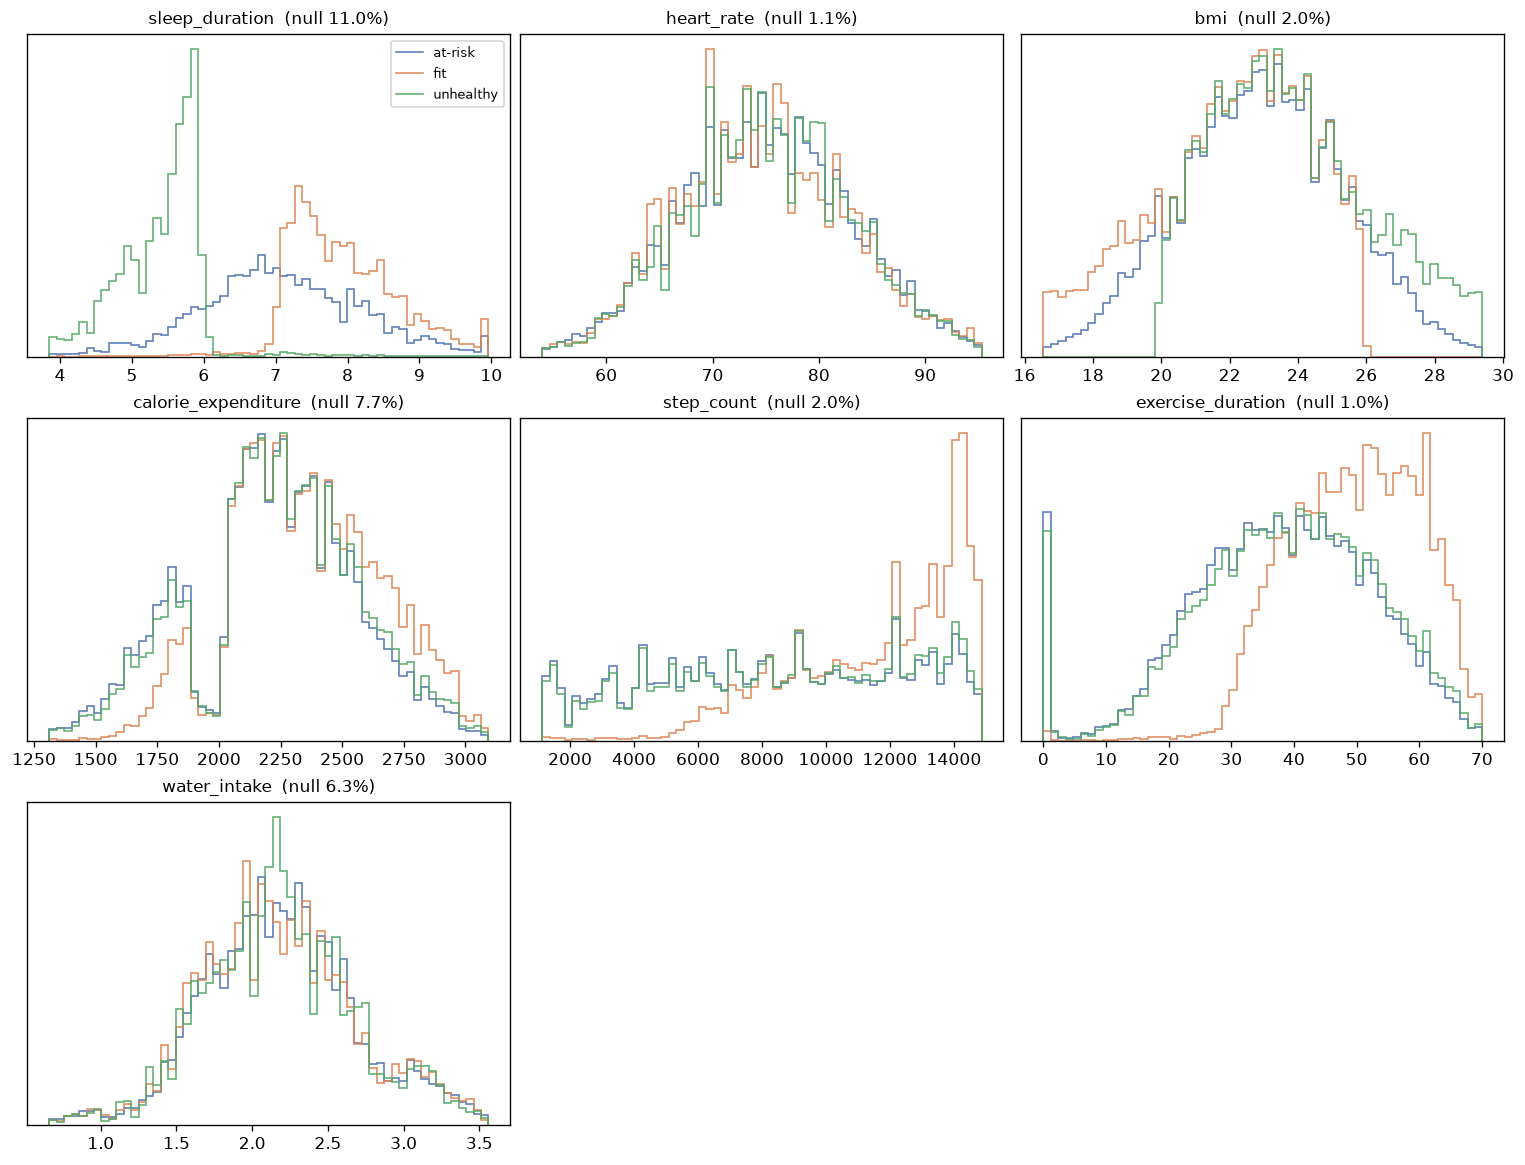

In [14]:
# The densities behind the d values — blind spot #2 (equal means, different variances)
# and blind spot #3 (which class separates from which) are only visible here.
plots.numeric_grid(train, io.NUMERIC_COLS, io.TARGET)

## Step 7 — redundancy between numerics

**Decision:** which features are duplicates of each other.

Spearman is Pearson's correlation computed on the **ranks** instead of the values. Being
rank-based, it catches monotone-but-curved relationships that Pearson underestimates, and
no outlier can move it. Nulls drop pairwise, so `n_pairs` shows how many rows each figure
actually rests on.

**Read $\rho^2$, not $\rho$** — the fraction of variance (of the ranks) that one column
explains in the other:

$$\rho = 0.3 \to 9\% \qquad \rho = 0.5 \to 25\% \qquad
\rho = 0.7 \to 49\% \qquad \rho = 0.95 \to 90\%$$

$\rho$ reads far larger than it is. That is why the redundancy threshold sits near 0.95
rather than at a number that merely *sounds* high — at $\rho = 0.7$ the two columns still
disagree about half the time. Two columns above the threshold are one feature wearing two
hats: the second adds no information, splits the importance between them so neither looks
strong, and destabilises any linear model in the blend.

One caveat: $\rho^2 = 0$ means no **monotone** association, not independence. $y = x^2$
on symmetric $x$ has $\rho \approx 0$ and is perfectly determined.

A GBDT itself tolerates the redundancy — read this table as a pruning list for the day a
linear model or a network joins the blend.

In [15]:
eda.numeric_correlation(train, io.NUMERIC_COLS)

col_a,col_b,n_pairs,spearman,abs
str,str,i64,f64,f64
"""step_count""","""exercise_duration""",669402,0.4413,0.4413
"""calorie_expenditure""","""exercise_duration""",630836,0.3698,0.3698
"""calorie_expenditure""","""step_count""",624390,0.3667,0.3667
"""bmi""","""calorie_expenditure""",624389,0.1098,0.1098
"""sleep_duration""","""bmi""",601658,-0.0613,0.0613
"""bmi""","""step_count""",662540,-0.0176,0.0176
"""bmi""","""exercise_duration""",669419,-0.0174,0.0174
"""heart_rate""","""exercise_duration""",675423,-0.007,0.007
"""heart_rate""","""step_count""",668491,-0.0064,0.0064


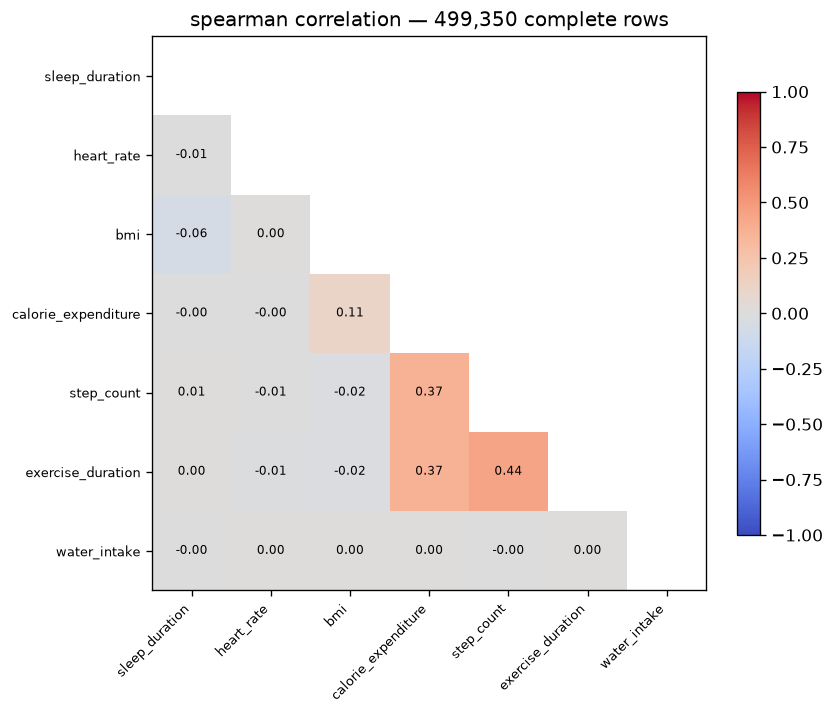

In [16]:
plots.correlation(train, io.NUMERIC_COLS)